In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

from pathlib import Path
from IPython.display import Markdown, display

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11, 'pdf.fonttype': 42})

## Input

- `timestamp_utc` is the common key; timezone-aware `Europe/Berlin` time is used for daily, weekly, and Peak patterns.
- Load, shape-factor, actual-load, and imbalance data contain 35,136 quarter-hours. Day-Ahead prices are hourly values repeated over four quarter-hours.
- Energy is measured in MWh, average load in MW, and prices in EUR/MWh.
- Peak means Monday-Friday from 08:00 to 20:00 local time. The timestamps already include both daylight-saving clock changes, so no additional adjustment is applied.

In [81]:
data_dir = Path('../Data')
results_dir = Path('../Results')
figures_dir = results_dir / 'Figures'
table_dir = results_dir / 'Table'
output_data_dir = results_dir / 'Output Data'
for output_dir in [figures_dir, table_dir, output_data_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

slp = pd.read_csv(data_dir / 'slp_profiles.csv')
futures = pd.read_csv(data_dir / 'futures_prices.csv')
shape_factors = pd.read_csv(data_dir / 'shape_factors.csv')
day_ahead = pd.read_csv(data_dir / 'day_ahead_prices.csv')
actual_load = pd.read_csv(data_dir / 'actual_portfolio_load.csv')
imbalance = pd.read_csv(data_dir / 'imbalance_prices.csv')
data_dictionary = pd.read_csv(data_dir / 'data_dictionary.csv')
sources = pd.read_csv(data_dir / 'sources.csv')

In [82]:
datasets = {'slp_profiles': slp, 'futures_prices': futures, 'shape_factors': shape_factors, 'day_ahead_prices': day_ahead, 'actual_portfolio_load': actual_load, 'imbalance_prices': imbalance, 'data_dictionary': data_dictionary, 'sources': sources}
data_summary = []
for name, data in datasets.items():
    missing_values = int(data.isna().sum().sum())
    data_summary.append({'dataset': name, 'rows': len(data), 'columns': data.shape[1], 'missing_values': missing_values})
data_summary = pd.DataFrame(data_summary)
display(data_summary)

,dataset,rows,columns,missing_values
0,slp_profiles,35136,5,0
1,futures_prices,34,9,0
2,shape_factors,35136,7,0
3,day_ahead_prices,35136,3,0
4,actual_portfolio_load,35136,6,0
5,imbalance_prices,35136,3,0
6,data_dictionary,33,4,0
7,sources,7,4,2


Your company supplies the following customers:

| Profile | Customer type | Customers | Annual consumption per customer |
| --- | --- | --- | --- |
| HB | Household | 10,000 | 3.5 MWh |
| GB | General commercial  | 200 | 30.0 MWh |
| LB | Agriculture | 20 | 100.0 MWh |

Stromnetz Berlin provides a standardized quarter-hourly load profile for each customer type. These profiles describe how annual consumption is distributed over time

## Exhibit 1 - Customer portfolio

**Inputs:** the customer table in Section 2 and `slp_profiles.csv`  


In [83]:
display(data_dictionary[data_dictionary['file'].eq('slp_profiles.csv')])
display(slp.head())
display(slp.describe())

,file,column,description,data_status
0,slp_profiles.csv,timestamp_utc,Quarter-hour start in UTC; primary join key.,observed/preprocessed
1,slp_profiles.csv,timestamp_local,Quarter-hour start in Europe/Berlin with UTC o...,observed/preprocessed
2,slp_profiles.csv,hb_normalized_kwh,"Berlin household SLP energy; annual sum is 1,0...",observed
3,slp_profiles.csv,gb_normalized_kwh,Berlin general-commercial SLP energy; annual s...,observed
4,slp_profiles.csv,lb_normalized_kwh,Berlin agricultural SLP energy; annual sum is ...,observed


,timestamp_utc,timestamp_local,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,27.110,15.705,17.028
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,25.127,15.158,16.454
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,23.237,14.636,16.030
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,21.409,14.164,15.706
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,19.643,13.741,15.482


,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh
count,35136.000000,35136.000000,35136.000000
mean,28.460838,28.460838,28.460838
std,12.231758,14.592604,12.078491
min,9.102000,10.387000,12.315000
25%,17.272500,16.973000,17.301000
50%,29.791000,21.322000,26.699000
75%,36.163250,43.190000,37.045000
max,66.992000,59.741000,59.930000


In [84]:
profile_columns = ['hb_normalized_kwh', 'gb_normalized_kwh', 'lb_normalized_kwh']
profile_names = {'hb_normalized_kwh': 'HB: Household', 'gb_normalized_kwh': 'GB: General Commercial', 'lb_normalized_kwh': 'LB: Agriculture'}
profile_colors = {'hb_normalized_kwh': 'royalblue', 'gb_normalized_kwh': 'salmon', 'lb_normalized_kwh': 'gray'}
profile_line_styles = {'hb_normalized_kwh': '-', 'gb_normalized_kwh': '-', 'lb_normalized_kwh': '-'}

slp_quality = pd.DataFrame({
    'rows': [len(slp)], 'start_local': [slp['timestamp_local'].min()], 'end_local': [slp['timestamp_local'].max()],
    'unique_utc': [slp['timestamp_utc'].nunique()], 'duplicate_utc': [slp['timestamp_utc'].duplicated().sum()], 'duplicate_rows': [slp.duplicated().sum()],
    'missing_values': [slp[['timestamp_utc', 'timestamp_local'] + profile_columns].isna().sum().sum()], 'negative_profile_values': [slp[profile_columns].lt(0).sum().sum()]
}, index=['slp_quality'])

print(slp_quality.T.to_string(header=False))

rows                                         35136
start_local              2024-01-01T00:00:00+01:00
end_local                2024-12-31T23:45:00+01:00
unique_utc                                   35136
duplicate_utc                                    0
duplicate_rows                                   0
missing_values                                   0
negative_profile_values                          0


---
Annual portfolio energy for customer group (p):

$$
E_p=n_p e_p
$$

Convert the supplied normalized SLP from kWh to annual MWh and derive one scaling factor for every quarter-hour:

$$
\text{annual\_slp\_mwh}_p=\frac{\sum_t s_{p,t}^{\mathrm{kWh}}}{1000},
\qquad
\text{scaling\_factor}_p=\frac{E_p}{\text{annual\_slp\_mwh}_p}
$$

$$
L_{p,t}^{\mathrm{MWh}}=\frac{s_{p,t}^{\mathrm{kWh}}\times\text{scaling\_factor}_p}{1000},
\qquad
\text{share}_p=\frac{E_p}{\sum_q E_q}
$$

Aggregate customer groups:

$$
L_t^{\mathrm{MWh}}=\sum_p L_{p,t}^{\mathrm{MWh}},
$$

In [85]:
num_customers = np.array([10000, 200, 20]) # n_p
consumption_per_customer = np.array([3.5, 30.0, 100.0]) # e_p, MWh
consumption_per_class = num_customers * consumption_per_customer # E_p, MWh

annual_slp_mwh = slp[profile_columns].sum().values / 1000
scaling_factors = consumption_per_class / annual_slp_mwh

profile_summary = pd.DataFrame({
    'Profile': ['HB', 'GB', 'LB'],
    'Customers': num_customers,
    'Annual MWh per Customer': consumption_per_customer,
    'Annual MWh': consumption_per_class,
    'Energy Share %': consumption_per_class / consumption_per_class.sum() * 100,
    'SLP Annual MWh': annual_slp_mwh,
    'Scaling Factor': scaling_factors
})

profile_summary.loc[len(profile_summary)] = {
    'Profile': 'Total',
    'Customers': num_customers.sum(),
    'Annual MWh per Customer': consumption_per_class.sum() / num_customers.sum(),
    'Annual MWh': consumption_per_class.sum(),
    'Energy Share %': 100.0,
    'SLP Annual MWh': annual_slp_mwh.sum(),
    'Scaling Factor': np.nan
}

print('Customer Portfolio')
print(profile_summary[['Profile', 'Customers', 'Annual MWh per Customer', 'Annual MWh', 'Energy Share %', 'SLP Annual MWh', 'Scaling Factor']].round({'Annual MWh per Customer': 1, 'Annual MWh': 1, 'Energy Share %': 2}).to_string(index=False))

Customer Portfolio
Profile  Customers  Annual MWh per Customer  Annual MWh  Energy Share %  SLP Annual MWh  Scaling Factor
     HB      10000                      3.5     35000.0           81.40          1000.0            35.0
     GB        200                     30.0      6000.0           13.95          1000.0             6.0
     LB         20                    100.0      2000.0            4.65          1000.0             2.0
  Total      10220                      4.2     43000.0          100.00          3000.0             NaN


In [86]:
customer_profile = slp[['timestamp_utc', 'timestamp_local']].copy()
customer_profile['hb_mwh'] = slp['hb_normalized_kwh'] * scaling_factors[0] / 1000
customer_profile['gb_mwh'] = slp['gb_normalized_kwh'] * scaling_factors[1] / 1000
customer_profile['lb_mwh'] = slp['lb_normalized_kwh'] * scaling_factors[2] / 1000
customer_profile['total_mwh'] = customer_profile[['hb_mwh', 'gb_mwh', 'lb_mwh']].sum(axis=1) # L_t

display(customer_profile.round({'hb_mwh': 6, 'gb_mwh': 6, 'lb_mwh': 6, 'total_mwh': 6}))

,timestamp_utc,timestamp_local,hb_mwh,gb_mwh,lb_mwh,total_mwh
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,0.948850,0.094230,0.034056,1.077136
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,0.879445,0.090948,0.032908,1.003301
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,0.813295,0.087816,0.032060,0.933171
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,0.749315,0.084984,0.031412,0.865711
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,0.687505,0.082446,0.030964,0.800915
...,...,...,...,...,...,...
35131,2024-12-31T21:45:00Z,2024-12-31T22:45:00+01:00,1.299935,0.110040,0.044324,1.454299
35132,2024-12-31T22:00:00Z,2024-12-31T23:00:00+01:00,1.247155,0.106908,0.041882,1.395945
35133,2024-12-31T22:15:00Z,2024-12-31T23:15:00+01:00,1.181145,0.103926,0.039538,1.324609
35134,2024-12-31T22:30:00Z,2024-12-31T23:30:00+01:00,1.108590,0.100794,0.037394,1.246778


In [87]:
customer_profile['total_mw'] = customer_profile['total_mwh'] / 0.25

energy_reconciliation = pd.DataFrame({
    'Customer Group': ['HB', 'GB', 'LB', 'Total'],
    'Expected MWh': np.append(consumption_per_class, consumption_per_class.sum()),
    'Calculated MWh': np.append(customer_profile[['hb_mwh', 'gb_mwh', 'lb_mwh']].sum().values, customer_profile['total_mwh'].sum())
})

energy_reconciliation['Difference MWh'] = energy_reconciliation['Calculated MWh'] - energy_reconciliation['Expected MWh']
energy_reconciliation['Energy Share pct'] = energy_reconciliation['Calculated MWh'] / customer_profile['total_mwh'].sum() * 100
energy_reconciliation['Reconciled'] = np.isclose(energy_reconciliation['Calculated MWh'], energy_reconciliation['Expected MWh'], rtol=0, atol=1e-8)

print(energy_reconciliation.round({'Expected MWh': 3, 'Calculated MWh': 3, 'Difference MWh': 10, 'Energy Share pct': 2}).to_string(index=False))

Customer Group  Expected MWh  Calculated MWh  Difference MWh  Energy Share pct  Reconciled
            HB       35000.0         35000.0             0.0             81.40        True
            GB        6000.0          6000.0            -0.0             13.95        True
            LB        2000.0          2000.0             0.0              4.65        True
         Total       43000.0         43000.0             0.0            100.00        True


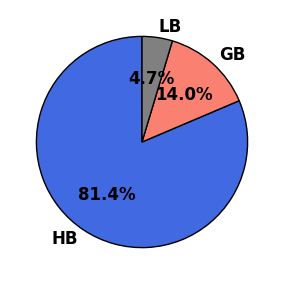

In [88]:
annual_energy_chart = profile_summary.loc[profile_summary['Profile'].ne('Total'), ['Profile', 'Annual MWh', 'Energy Share %']]

plt.figure(figsize=(4, 3))
plt.pie(annual_energy_chart['Annual MWh'], labels=annual_energy_chart['Profile'], autopct='%1.1f%%', colors=['royalblue', 'salmon', 'gray'], startangle=90, wedgeprops={'edgecolor': 'black'}, textprops={'fontweight': 'bold'})
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 1 Annual Energy Pie Chart.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 1 Annual Energy Pie Chart.png', dpi=300, transparent=True)
plt.show()

Average Daily Intervals: 96


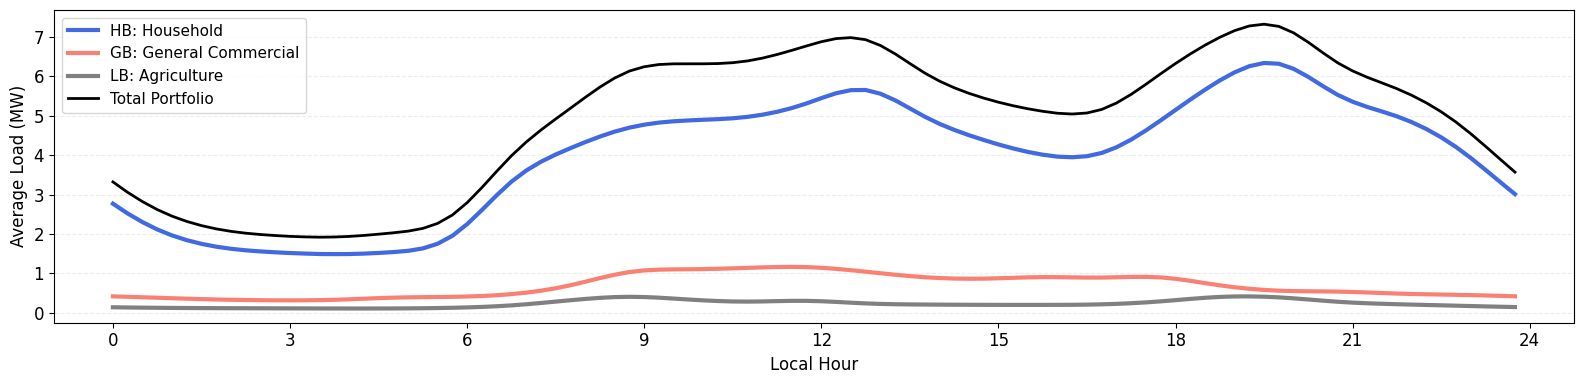

In [89]:
customer_profile['timestamp_utc'] = pd.to_datetime(customer_profile['timestamp_utc'], utc=True)
customer_profile['timestamp_local'] = customer_profile['timestamp_utc'].dt.tz_convert('Europe/Berlin')
customer_profile['local_quarter'] = customer_profile['timestamp_local'].dt.hour * 4 + customer_profile['timestamp_local'].dt.minute // 15

average_daily_shape = customer_profile.groupby('local_quarter')[['hb_mwh', 'gb_mwh', 'lb_mwh', 'total_mwh']].mean() / 0.25
average_daily_shape.index = average_daily_shape.index / 4

print('Average Daily Intervals:', len(average_daily_shape))

plt.figure(figsize=(16, 4))
plt.plot(average_daily_shape.index, average_daily_shape['hb_mwh'], color=profile_colors['hb_normalized_kwh'], linestyle=profile_line_styles['hb_normalized_kwh'], linewidth=3, label=profile_names['hb_normalized_kwh'])
plt.plot(average_daily_shape.index, average_daily_shape['gb_mwh'], color=profile_colors['gb_normalized_kwh'], linestyle=profile_line_styles['gb_normalized_kwh'], linewidth=3, label=profile_names['gb_normalized_kwh'])
plt.plot(average_daily_shape.index, average_daily_shape['lb_mwh'], color=profile_colors['lb_normalized_kwh'], linestyle=profile_line_styles['lb_normalized_kwh'], linewidth=3, label=profile_names['lb_normalized_kwh'])
plt.plot(average_daily_shape.index, average_daily_shape['total_mwh'], color='black', linestyle='-', linewidth=2, label='Total Portfolio')
plt.xlabel('Local Hour')
plt.ylabel('Average Load (MW)')
plt.xticks(np.arange(0, 25, 3))
plt.xlim(-1, 24.75)
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 1 Average Daily Profiles.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 1 Average Daily Profiles.png', dpi=300, transparent=True)
plt.show()

    Day  HB MWh  GB MWh  LB MWh  Total MWh
    Mon  93.897  17.869   5.501    117.266
    Tue  94.267  18.259   5.488    118.014
    Wed  93.591  17.992   5.481    117.064
    Thu  93.742  17.805   5.472    117.019
    Fri  93.600  17.992   5.481    117.073
Weekday  93.822  17.984   5.484    117.290
                                          
    Sat 103.815  15.479   5.273    124.568
    Sun  96.545   9.294   5.556    111.395
Weekend 100.180  12.387   5.415    117.981


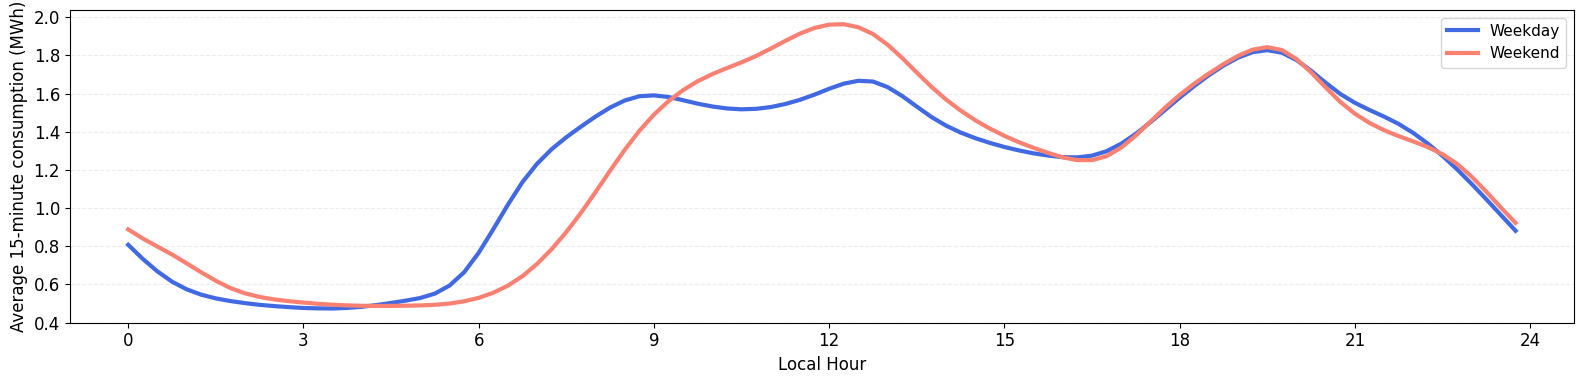

In [90]:
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Weekday', 'Sat', 'Sun', 'Weekend']

customer_profile['local_date'] = customer_profile['timestamp_local'].dt.date
customer_profile['day_name'] = customer_profile['timestamp_local'].dt.weekday.map(day_names)
customer_profile['day_type'] = np.where(customer_profile['timestamp_local'].dt.weekday < 5, 'Weekday', 'Weekend')

daily_consumption = customer_profile.groupby(['local_date', 'day_name', 'day_type'], as_index=False)[['hb_mwh', 'gb_mwh', 'lb_mwh', 'total_mwh']].sum()
day_consumption = daily_consumption.groupby('day_name')[['hb_mwh', 'gb_mwh', 'lb_mwh', 'total_mwh']].mean()
day_type_consumption = daily_consumption.groupby('day_type')[['hb_mwh', 'gb_mwh', 'lb_mwh', 'total_mwh']].mean()

weekday_weekend_consumption = pd.concat([day_consumption, day_type_consumption]).reindex(day_order).rename_axis('Day').reset_index()
weekday_weekend_consumption.columns = ['Day', 'HB MWh', 'GB MWh', 'LB MWh', 'Total MWh']

blank_row = pd.DataFrame([{'Day': ''}])
weekday_weekend_consumption = pd.concat([weekday_weekend_consumption.iloc[:6], blank_row, weekday_weekend_consumption.iloc[6:]], ignore_index=True)

print(weekday_weekend_consumption.round({'HB MWh': 3, 'GB MWh': 3, 'LB MWh': 3, 'Total MWh': 3}).to_string(index=False, na_rep=''))

weekday_weekend_profile = customer_profile.groupby(['local_quarter', 'day_type'])['total_mwh'].mean().unstack('day_type')
weekday_weekend_profile.index = weekday_weekend_profile.index / 4

plt.figure(figsize=(16, 4))
plt.plot(weekday_weekend_profile.index, weekday_weekend_profile['Weekday'], color='royalblue', linestyle='-', linewidth=3, label='Weekday')
plt.plot(weekday_weekend_profile.index, weekday_weekend_profile['Weekend'], color='salmon', linestyle='-', linewidth=3, label='Weekend')
plt.xlabel('Local Hour')
plt.ylabel('Average 15-minute consumption (MWh)')
plt.xticks(np.arange(0, 25, 3))
plt.xlim(-1, 24.75)
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 1 Weekday vs Weekend.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 1 Weekday vs Weekend.png', dpi=300, transparent=True)
plt.show()

In [91]:
weekday_total = day_type_consumption.loc['Weekday', 'total_mwh']
weekend_total = day_type_consumption.loc['Weekend', 'total_mwh']
hb_peak_time = (pd.Timestamp('2000-01-01') + pd.to_timedelta(average_daily_shape['hb_mwh'].idxmax(), unit='h')).strftime('%H:%M')
gb_peak_time = (pd.Timestamp('2000-01-01') + pd.to_timedelta(average_daily_shape['gb_mwh'].idxmax(), unit='h')).strftime('%H:%M')
total_peak_time = (pd.Timestamp('2000-01-01') + pd.to_timedelta(average_daily_shape['total_mwh'].idxmax(), unit='h')).strftime('%H:%M')
slp_annual_text = ', '.join(f'{profile}: {value:,.0f} MWh' for profile, value in zip(['HB', 'GB', 'LB'], annual_slp_mwh))
scaling_text = ', '.join(f'{profile}: {value:g}' for profile, value in zip(['HB', 'GB', 'LB'], scaling_factors))
maximum_reconciliation_difference = energy_reconciliation['Difference MWh'].abs().max()

display(Markdown(f"""
### Interpretation

- **Portfolio mix:** Annual forecast consumption is **{customer_profile['total_mwh'].sum():,.0f} MWh**. HB supplies **{profile_summary.loc[profile_summary['Profile'].eq('HB'), 'Annual MWh'].iloc[0]:,.0f} MWh ({profile_summary.loc[profile_summary['Profile'].eq('HB'), 'Energy Share %'].iloc[0]:.1f}%)**, so the total profile is strongly household-driven.
- **Scaling:** The scaling factors are **{scaling_text}**
- **Daily shape:** HB and the total portfolio peak at about **{hb_peak_time}** and **{total_peak_time}**; GB peaks earlier at about **{gb_peak_time}**.
- **Weekday versus weekend:** Average daily energy is **{weekday_total:.2f} MWh** on weekdays and **{weekend_total:.2f} MWh** on weekends. Weekday demand rises earlier from roughly 06:00-09:00, weekend demand shifts toward late morning/noon and is slightly higher overnight, while their evening profiles are comparatively similar.
"""))


### Interpretation

- **Portfolio mix:** Annual forecast consumption is **43,000 MWh**. HB supplies **35,000 MWh (81.4%)**, so the total profile is strongly household-driven.
- **Scaling:** The scaling factors are **HB: 35, GB: 6, LB: 2**
- **Daily shape:** HB and the total portfolio peak at about **19:30** and **19:30**; GB peaks earlier at about **11:30**.
- **Weekday versus weekend:** Average daily energy is **117.29 MWh** on weekdays and **117.98 MWh** on weekends. Weekday demand rises earlier from roughly 06:00-09:00, weekend demand shifts toward late morning/noon and is slightly higher overnight, while their evening profiles are comparatively similar.


## Exhibit 2 - Futures market

**File:** `futures_prices.csv`

The file contains Year, Quarter, and Month products. Base covers every hour of its delivery period; Peak covers only the defined weekday Peak hours. `market_activity` is a simplified indicator of tradability. 

In [92]:
display(data_dictionary[data_dictionary['file'].eq('futures_prices.csv')])
display(futures.head())

,file,column,description,data_status
5,futures_prices.csv,quote_date,Date of the teaching futures snapshot.,synthetic
6,futures_prices.csv,delivery_year,Calendar year in which the product delivers.,synthetic
7,futures_prices.csv,load_type,BASE delivers in all intervals; PEAK only in t...,synthetic
8,futures_prices.csv,product_type,"YEAR, QUARTER, or MONTH delivery product.",synthetic
9,futures_prices.csv,delivery_period,"Product delivery label such as CAL, Q1, or M01.",synthetic
10,futures_prices.csv,delivery_start,Inclusive delivery-period start date.,synthetic
11,futures_prices.csv,delivery_end_exclusive,Exclusive delivery-period end date.,synthetic
12,futures_prices.csv,price_eur_mwh,Teaching forward price in EUR/MWh.,synthetic
13,futures_prices.csv,market_activity,Teaching tradability indicator; higher values ...,synthetic


,quote_date,delivery_year,load_type,product_type,delivery_period,delivery_start,delivery_end_exclusive,price_eur_mwh,market_activity
0,2023-09-29,2024,BASE,YEAR,CAL,2024-01-01,2025-01-01,77.26,5000
1,2023-09-29,2024,PEAK,YEAR,CAL,2024-01-01,2025-01-01,86.60,1400
2,2023-09-29,2024,BASE,QUARTER,Q1,2024-01-01,2024-04-01,66.42,3000
3,2023-09-29,2024,PEAK,QUARTER,Q1,2024-01-01,2024-04-01,77.70,840
4,2023-09-29,2024,BASE,QUARTER,Q2,2024-04-01,2024-07-01,66.23,2200


In [93]:
market_activity_threshold = 100
futures_data = futures.copy()
for column in ['quote_date', 'delivery_start', 'delivery_end_exclusive']:
    futures_data[column] = pd.to_datetime(futures_data[column])
futures_data['activity_eligible'] = futures_data['market_activity'].ge(market_activity_threshold)

futures_quality = pd.DataFrame({
    'rows': [len(futures_data)], 'quote_date': [futures_data['quote_date'].min().date()], 'missing_values': [futures_data.isna().sum().sum()],
    'duplicate_rows': [futures_data.duplicated().sum()], 'duplicate_contract_keys': [futures_data.duplicated(['delivery_period', 'load_type']).sum()],
    'base_contracts': [futures_data['load_type'].eq('BASE').sum()], 'peak_contracts': [futures_data['load_type'].eq('PEAK').sum()],
    'year_contracts': [futures_data['product_type'].eq('YEAR').sum()], 'quarter_contracts': [futures_data['product_type'].eq('QUARTER').sum()], 'month_contracts': [futures_data['product_type'].eq('MONTH').sum()]
}, index=['futures_quality'])
print(futures_quality.T.to_string(header=False))

futures_market = futures_data.pivot(index=['product_type', 'delivery_period'], columns='load_type', values=['price_eur_mwh', 'market_activity', 'activity_eligible']).reset_index()
futures_market.columns = ['_'.join(str(part) for part in column if part).lower() for column in futures_market.columns]
futures_market['peak_minus_base_eur_mwh'] = futures_market['price_eur_mwh_peak'] - futures_market['price_eur_mwh_base']
futures_market['min_market_activity'] = futures_market[['market_activity_base', 'market_activity_peak']].min(axis=1)
futures_market['base_peak_eligible'] = futures_market['activity_eligible_base'].astype(bool) & futures_market['activity_eligible_peak'].astype(bool)
futures_market['status'] = np.where(futures_market['base_peak_eligible'], 'Usable', 'Illiquid')
period_order = ['CAL', 'Q1', 'Q2', 'Q3', 'Q4'] + [f'M{month:02d}' for month in range(1, 13)]
futures_market['order'] = futures_market['delivery_period'].map({period: order for order, period in enumerate(period_order)})
futures_market = futures_market.sort_values('order').reset_index(drop=True)

futures_market_table = futures_market[['product_type', 'delivery_period', 'price_eur_mwh_base', 'price_eur_mwh_peak', 'peak_minus_base_eur_mwh', 'market_activity_base', 'market_activity_peak', 'status']].rename(columns={'product_type': 'Type', 'delivery_period': 'Period', 'price_eur_mwh_base': 'Base Price', 'price_eur_mwh_peak': 'Peak Price', 'peak_minus_base_eur_mwh': 'Peak - Base', 'market_activity_base': 'Base Activity', 'market_activity_peak': 'Peak Activity', 'status': 'Status'})
highest_below_threshold = futures_data.loc[~futures_data['activity_eligible'], 'market_activity'].max()
lowest_above_threshold = futures_data.loc[futures_data['activity_eligible'], 'market_activity'].min()
usable_periods = futures_market.loc[futures_market['base_peak_eligible'], 'delivery_period'].tolist()
illiquid_periods = futures_market.loc[~futures_market['base_peak_eligible'], 'delivery_period'].tolist()

print("\n")
print(futures_market_table.round({'Base Price': 2, 'Peak Price': 2, 'Peak - Base': 2}).to_string(index=False))

rows                             34
quote_date               2023-09-29
missing_values                    0
duplicate_rows                    0
duplicate_contract_keys           0
base_contracts                   17
peak_contracts                   17
year_contracts                    2
quarter_contracts                 8
month_contracts                  24


   Type Period Base Price Peak Price Peak - Base Base Activity Peak Activity   Status
   YEAR    CAL      77.26       86.6        9.34          5000          1400   Usable
QUARTER     Q1      66.42       77.7       11.28          3000           840   Usable
QUARTER     Q2      66.23      64.76       -1.47          2200           616   Usable
QUARTER     Q3      74.74      69.07       -5.67          1600           448   Usable
QUARTER     Q4     101.39     134.42       33.03          1400           392   Usable
  MONTH    M01      75.32      88.68       13.36           900           252   Usable
  MONTH    M02      60.09      70.59

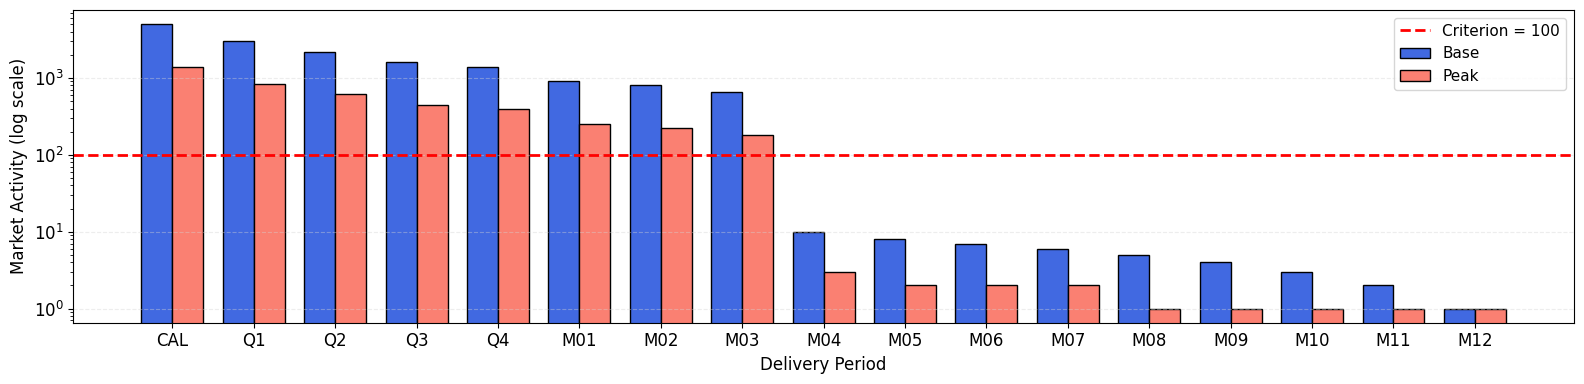

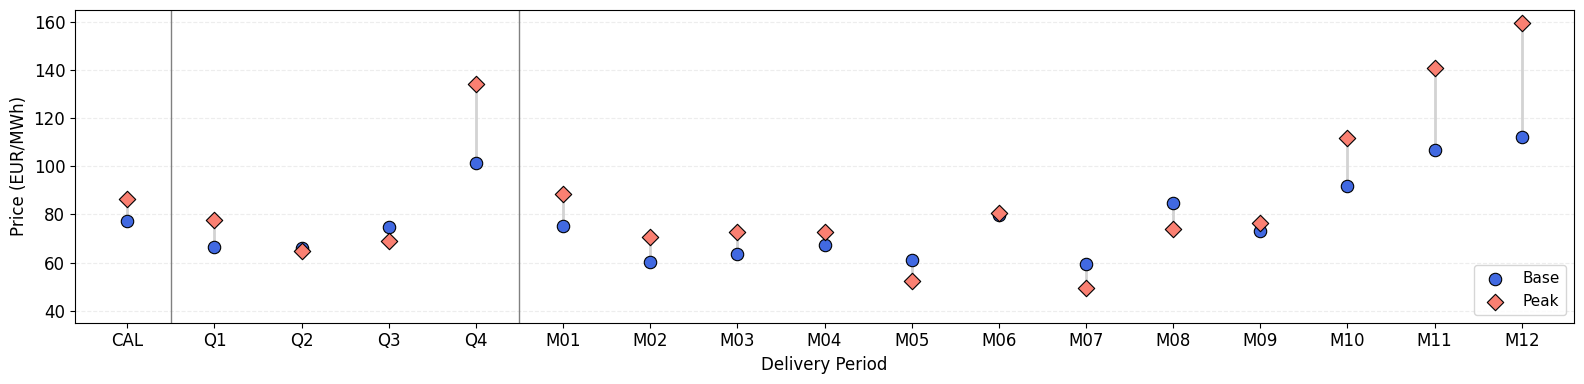

In [94]:
x = np.arange(len(futures_market))
width = 0.38

plt.figure(figsize=(16, 4))
plt.bar(x - width / 2, futures_market['market_activity_base'], width=width, color='royalblue', edgecolor='black', label='Base')
plt.bar(x + width / 2, futures_market['market_activity_peak'], width=width, color='salmon', edgecolor='black', label='Peak')
plt.axhline(market_activity_threshold, color='red', linestyle='--', linewidth=2, label=f'Criterion = {market_activity_threshold}')
plt.yscale('log')
plt.xlabel('Delivery Period')
plt.ylabel('Market Activity (log scale)')
plt.xticks(x, futures_market['delivery_period'])
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 2 Market Activity.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 2 Market Activity.png', dpi=300, transparent=True)
plt.show()

base_price = futures_market['price_eur_mwh_base'].to_numpy()
peak_price = futures_market['price_eur_mwh_peak'].to_numpy()
price_min = np.floor(min(base_price.min(), peak_price.min()) / 10) * 10 - 5
price_max = np.ceil(max(base_price.max(), peak_price.max()) / 10) * 10 + 5

plt.figure(figsize=(16, 4))
plt.vlines(x, np.minimum(base_price, peak_price), np.maximum(base_price, peak_price), color='lightgray', linewidth=2, zorder=1)
plt.scatter(x, base_price, s=80, color='royalblue', edgecolor='black', linewidth=0.8, marker='o', label='Base', zorder=3)
plt.scatter(x, peak_price, s=70, color='salmon', edgecolor='black', linewidth=0.8, marker='D', label='Peak', zorder=3)
plt.axvline(0.5, color='gray', linewidth=1)
plt.axvline(4.5, color='gray', linewidth=1)
plt.xlabel('Delivery Period')
plt.ylabel('Price (EUR/MWh)')
plt.xticks(x, futures_market['delivery_period'])
plt.xlim(-0.6, len(futures_market) - 0.4)
plt.ylim(price_min, price_max)
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 2 Futures Prices.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 2 Futures Prices.png', dpi=300, transparent=True)
plt.show()

In [95]:
coverage_sets = {'COARSE_CAL': ['CAL'], 'Q1-Q4 coverage': ['Q1', 'Q2', 'Q3', 'Q4'], 'GRANULAR': ['M01', 'M02', 'M03', 'Q2', 'Q3', 'Q4']}
coverage = pd.DataFrame([{'Coverage': coverage_name, 'Products': ', '.join(periods)} for coverage_name, periods in coverage_sets.items()])
q4_market = futures_market.loc[futures_market['delivery_period'].eq('Q4')].iloc[0]
negative_spreads = futures_market.loc[futures_market['peak_minus_base_eur_mwh'].lt(0)].set_index('delivery_period')['peak_minus_base_eur_mwh']
negative_spread_text = ', '.join(f'{period} ({value:.2f} EUR/MWh)' for period, value in negative_spreads.items())
lower_peak_activity = futures_market.loc[futures_market['market_activity_peak'].lt(futures_market['market_activity_base']), 'delivery_period'].tolist()
equal_peak_activity = futures_market.loc[futures_market['market_activity_peak'].eq(futures_market['market_activity_base']), 'delivery_period'].tolist()

print(coverage.to_string(index=False))
display(Markdown(f"""
### Interpretation

- **Available market:** The **{futures_quality.loc['futures_quality', 'quote_date']}** snapshot contains **{len(futures_data)} contracts**: **{futures_quality.loc['futures_quality', 'base_contracts']} Base** and **{futures_quality.loc['futures_quality', 'peak_contracts']} Peak**, spanning CAL, Q1-Q4, and M01-M12.
- **Tradability:** Requiring `market_activity >= {market_activity_threshold}` for both Base and Peak classifies **{', '.join(usable_periods)}** as usable and **{', '.join(illiquid_periods)}** as illiquid. The gap from **{highest_below_threshold:.0f}** to **{lowest_above_threshold:.0f}** makes the classification transparent, but the threshold remains an analytical assumption rather than an official liquidity rule.
- **Activity structure:** Peak activity is below Base in **{len(lower_peak_activity)} of {len(futures_market)} periods**; it is equal only for **{', '.join(equal_peak_activity)}**. Activity remains substantial through M03 and collapses from M04 onward.
- **Seasonality and spreads:** Q4 has the highest usable quarterly prices at **{q4_market['price_eur_mwh_base']:.2f} EUR/MWh** for Base and **{q4_market['price_eur_mwh_peak']:.2f} EUR/MWh** for Peak. M10-M12 quotes are also high but illiquid. Peak is not always more expensive than Base: **{negative_spread_text}**.
- **Coverage:** CAL is the coarse structure; M01-M03 followed by Q2-Q4 is the more granular liquid structure. The timeline shows why adding annual, quarterly, and monthly full-volume positions together would double-cover the same delivery intervals.
"""))

      Coverage                  Products
    COARSE_CAL                       CAL
Q1-Q4 coverage            Q1, Q2, Q3, Q4
      GRANULAR M01, M02, M03, Q2, Q3, Q4



### Interpretation

- **Available market:** The **2023-09-29** snapshot contains **34 contracts**: **17 Base** and **17 Peak**, spanning CAL, Q1-Q4, and M01-M12.
- **Tradability:** Requiring `market_activity >= 100` for both Base and Peak classifies **CAL, Q1, Q2, Q3, Q4, M01, M02, M03** as usable and **M04, M05, M06, M07, M08, M09, M10, M11, M12** as illiquid. The gap from **10** to **182** makes the classification transparent, but the threshold remains an analytical assumption rather than an official liquidity rule.
- **Activity structure:** Peak activity is below Base in **16 of 17 periods**; it is equal only for **M12**. Activity remains substantial through M03 and collapses from M04 onward.
- **Seasonality and spreads:** Q4 has the highest usable quarterly prices at **101.39 EUR/MWh** for Base and **134.42 EUR/MWh** for Peak. M10-M12 quotes are also high but illiquid. Peak is not always more expensive than Base: **Q2 (-1.47 EUR/MWh), Q3 (-5.67 EUR/MWh), M05 (-8.56 EUR/MWh), M07 (-9.98 EUR/MWh), M08 (-10.64 EUR/MWh)**.
- **Coverage:** CAL is the coarse structure; M01-M03 followed by Q2-Q4 is the more granular liquid structure. The timeline shows why adding annual, quarterly, and monthly full-volume positions together would double-cover the same delivery intervals.


## Exhibit 3 - Historical price shape

**File:** `shape_factors.csv`

The `historical_shape_factor` describes how prices varied by month, hour, and weekday in 2019-2022. It has an annual average close to one and is a relative shape rather than a price. 

In [96]:
display(data_dictionary[data_dictionary['file'].eq('shape_factors.csv')])
display(shape_factors.head())

,file,column,description,data_status
14,shape_factors.csv,timestamp_utc,Quarter-hour start in UTC; primary join key.,derived
15,shape_factors.csv,timestamp_local,Quarter-hour start in Europe/Berlin with UTC o...,derived
16,shape_factors.csv,month,"Local calendar month, from 1 to 12.",derived
17,shape_factors.csv,hour,"Local delivery hour, from 0 to 23.",derived
18,shape_factors.csv,weekday,Local weekday using Monday = 0 and Sunday = 6.,derived
19,shape_factors.csv,is_peak,"Peak flag: Monday-Friday, 08:00-20:00 Europe/B...",derived
20,shape_factors.csv,historical_shape_factor,Robust 2019-2022 Day-Ahead price shape normali...,derived


,timestamp_utc,timestamp_local,month,hour,weekday,is_peak,historical_shape_factor
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,1,0,0,0,0.832554
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,1,0,0,0,0.832554
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,1,0,0,0,0.832554
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,1,0,0,0,0.832554
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,1,1,0,0,0.796187


In [97]:
shape_data = shape_factors.copy()
shape_data['timestamp_utc'] = pd.to_datetime(shape_data['timestamp_utc'], utc=True)
shape_data['timestamp_local'] = shape_data['timestamp_utc'].dt.tz_convert('Europe/Berlin')
shape_data['day_type'] = np.where(shape_data['weekday'].lt(5), 'Weekday', 'Weekend')
shape_data['local_peak_check'] = shape_data['weekday'].lt(5) & shape_data['hour'].ge(8) & shape_data['hour'].lt(20)

shape_quality = pd.DataFrame({
    'rows': [len(shape_data)], 'unique_utc': [shape_data['timestamp_utc'].nunique()], 'duplicate_utc': [shape_data['timestamp_utc'].duplicated().sum()],
    'duplicate_rows': [shape_data.duplicated().sum()], 'missing_values': [shape_data.isna().sum().sum()], 'negative_shape_values': [shape_data['historical_shape_factor'].le(0).sum()],
    'annual_mean': [shape_data['historical_shape_factor'].mean()], 'standard_deviation': [shape_data['historical_shape_factor'].std()],
    'minimum': [shape_data['historical_shape_factor'].min()], '25%': [shape_data['historical_shape_factor'].quantile(0.25)], 'median': [shape_data['historical_shape_factor'].median()], '75%': [shape_data['historical_shape_factor'].quantile(0.75)], 'maximum': [shape_data['historical_shape_factor'].max()],
    'weekday_codes_valid': [set(shape_data['weekday'].unique()) == set(range(7))], 'peak_codes_valid': [set(shape_data['is_peak'].unique()) == {0, 1}],
    'peak_flag_mismatches': [shape_data['is_peak'].ne(shape_data['local_peak_check'].astype(int)).sum()]
}, index=['shape_quality'])
print(shape_quality.T.to_string(header=False))
print("\n")

shape_heatmap = shape_data.pivot_table(index='month', columns='hour', values='historical_shape_factor', aggfunc='mean')
weekday_heatmap = shape_data.loc[shape_data['day_type'].eq('Weekday')].pivot_table(index='month', columns='hour', values='historical_shape_factor', aggfunc='mean')
weekend_heatmap = shape_data.loc[shape_data['day_type'].eq('Weekend')].pivot_table(index='month', columns='hour', values='historical_shape_factor', aggfunc='mean')
display(shape_heatmap.round(3))

rows                      35136
unique_utc                35136
duplicate_utc                 0
duplicate_rows                0
missing_values                0
negative_shape_values         0
annual_mean                 1.0
standard_deviation     0.355565
minimum                0.122131
25%                      0.7605
median                 0.933293
75%                    1.141771
maximum                2.837606
weekday_codes_valid        True
peak_codes_valid           True
peak_flag_mismatches          0




hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,0.851,0.806,0.816,0.797,0.790,0.827,0.931,1.075,1.193,1.183,...,1.058,1.061,1.101,1.205,1.218,1.167,1.072,1.003,0.973,0.897
2,0.736,0.717,0.714,0.695,0.703,0.742,0.872,1.005,1.040,0.991,...,0.814,0.839,0.902,1.031,1.112,1.082,0.969,0.875,0.868,0.802
3,0.754,0.702,0.683,0.678,0.664,0.722,0.829,0.877,0.907,0.868,...,0.574,0.673,0.726,0.868,1.007,1.086,0.935,0.871,0.860,0.793
4,0.767,0.736,0.723,0.711,0.734,0.781,0.887,1.056,1.081,0.948,...,0.657,0.661,0.701,0.792,0.903,1.019,1.013,0.921,0.889,0.825
5,0.778,0.698,0.685,0.675,0.666,0.700,0.866,0.995,1.007,0.911,...,0.592,0.604,0.640,0.804,0.913,1.011,1.042,1.039,0.977,0.876
6,1.007,0.937,0.910,0.877,0.895,0.928,1.020,1.206,1.165,0.954,...,0.741,0.807,0.861,1.084,1.248,1.366,1.400,1.354,1.263,1.072
7,0.906,0.841,0.806,0.746,0.779,0.803,0.945,1.061,1.036,1.033,...,0.794,0.794,0.822,0.940,1.187,1.378,1.349,1.249,1.173,0.999
8,0.932,0.813,0.729,0.706,0.710,0.880,1.134,1.268,1.280,1.229,...,0.818,0.905,0.938,1.095,1.264,1.473,1.473,1.359,1.272,1.107
9,1.094,1.002,0.988,1.004,1.044,1.144,1.732,2.106,2.087,1.558,...,0.900,0.914,1.157,1.363,2.069,2.289,2.269,1.338,1.202,1.022


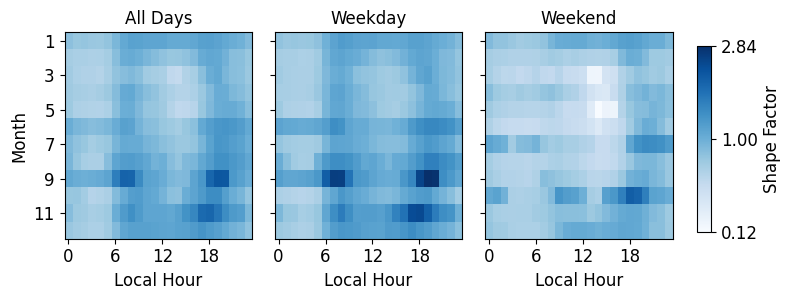

In [98]:
heatmap_min = min(shape_heatmap.min().min(), weekday_heatmap.min().min(), weekend_heatmap.min().min())
heatmap_max = max(shape_heatmap.max().max(), weekday_heatmap.max().max(), weekend_heatmap.max().max())
heatmap_norm = TwoSlopeNorm(vmin=heatmap_min, vcenter=1.0, vmax=heatmap_max)

fig, axes = plt.subplots(1, 3, figsize=(8, 3.1), sharex=True, sharey=True)

for axis, title, data in zip(axes, ['All Days', 'Weekday', 'Weekend'], [shape_heatmap, weekday_heatmap, weekend_heatmap]):
    image = axis.imshow(data, aspect='auto', cmap='Blues', norm=heatmap_norm)
    axis.set_box_aspect(1.1)
    axis.set_title(title)
    axis.set_xlabel('Local Hour')
    axis.set_xticks(np.arange(0, 24, 6))
    axis.set_xticklabels(np.arange(0, 24, 6))
    axis.set_yticks(np.arange(0, 12, 2))
    axis.set_yticklabels(np.arange(1, 13, 2))

axes[0].set_ylabel('Month')

fig.subplots_adjust(left=0.08, right=0.84, bottom=0.18, top=0.88, wspace=0.12)
colorbar_axis = fig.add_axes([0.87, 0.22, 0.018, 0.60])
colorbar = fig.colorbar(image, cax=colorbar_axis, ticks=[heatmap_min, 1.0, heatmap_max])
colorbar.ax.set_yticklabels([f'{heatmap_min:.2f}', '1.00', f'{heatmap_max:.2f}'])
colorbar.set_label('Shape Factor')

fig.savefig(figures_dir / 'Exhibit 3 Historical Price Shape.pdf', transparent=True, bbox_inches='tight')

fig.savefig(figures_dir / 'Exhibit 3 Historical Price Shape.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [99]:
all_high_month, all_high_hour = shape_heatmap.stack().idxmax()
all_low_month, all_low_hour = shape_heatmap.stack().idxmin()
weekday_ranked = weekday_heatmap.stack().sort_values()
weekend_ranked = weekend_heatmap.stack().sort_values()
peak_shape_mean = shape_data.groupby('is_peak')['historical_shape_factor'].mean()
day_type_shape_mean = shape_data.groupby('day_type')['historical_shape_factor'].mean()
hour_shape_mean = shape_data.groupby('hour')['historical_shape_factor'].mean()
month_shape_mean = shape_data.groupby('month')['historical_shape_factor'].mean()
above_average_hours = ', '.join(f'{hour:02d}:00' for hour in hour_shape_mean.loc[hour_shape_mean.gt(1)].index)
top_months = ', '.join(f'M{month:02d} ({value:.3f})' for month, value in month_shape_mean.nlargest(2).items())
weekday_top = ', '.join(f'M{month:02d} {hour:02d}:00 ({value:.3f})' for (month, hour), value in weekday_ranked.tail(5).sort_values(ascending=False).items())
weekend_top = ', '.join(f'M{month:02d} {hour:02d}:00 ({value:.3f})' for (month, hour), value in weekend_ranked.tail(5).sort_values(ascending=False).items())
weekday_bottom = ', '.join(f'M{month:02d} {hour:02d}:00 ({value:.3f})' for (month, hour), value in weekday_ranked.head(5).items())
weekend_bottom = ', '.join(f'M{month:02d} {hour:02d}:00 ({value:.3f})' for (month, hour), value in weekend_ranked.head(5).items())

display(Markdown(f"""
### Interpretation

- **Relative meaning:** The annual mean is **{shape_data['historical_shape_factor'].mean():.3f}**. Values above one identify historically above-average calendar patterns; values below one identify historically below-average patterns. The factor is dimensionless, not EUR/MWh.
- **Overall pattern:** The pooled month-hour maximum is **{shape_heatmap.loc[all_high_month, all_high_hour]:.3f}** in month **{all_high_month}** at **{all_high_hour:02d}:00**; the minimum is **{shape_heatmap.loc[all_low_month, all_low_hour]:.3f}** in month **{all_low_month}** at **{all_low_hour:02d}:00**. Across months and weekdays, the above-one hourly means occur at **{above_average_hours}**, and the two highest monthly means are **{top_months}**.
- **Weekdays:** The five highest month-hour factors are **{weekday_top}**; the five lowest are **{weekday_bottom}**. September and November contain pronounced morning or late-afternoon/evening concentrations.
- **Weekends:** The five highest month-hour factors are **{weekend_top}**; the five lowest are **{weekend_bottom}**. The weekday-style morning peak is weaker and the strongest evening pattern shifts across months.
- **Peak relationship:** Mean factors are **{peak_shape_mean.loc[1]:.3f}** in Peak and **{peak_shape_mean.loc[0]:.3f}** in Off-Peak, compared with **{day_type_shape_mean.loc['Weekday']:.3f}** on weekdays and **{day_type_shape_mean.loc['Weekend']:.3f}** on weekends. 
- **Economic role:** Futures quotes provide the market price level for broad blocks; normalized shape factors supply the seasonal, hourly, and weekday/weekend structure that those block averages conceal.
"""))


### Interpretation

- **Relative meaning:** The annual mean is **1.000**. Values above one identify historically above-average calendar patterns; values below one identify historically below-average patterns. The factor is dimensionless, not EUR/MWh.
- **Overall pattern:** The pooled month-hour maximum is **2.289** in month **9** at **19:00**; the minimum is **0.574** in month **3** at **14:00**. Across months and weekdays, the above-one hourly means occur at **06:00, 07:00, 08:00, 09:00, 10:00, 17:00, 18:00, 19:00, 20:00, 21:00, 22:00**, and the two highest monthly means are **M09 (1.356), M11 (1.229)**.
- **Weekdays:** The five highest month-hour factors are **M09 19:00 (2.838), M09 20:00 (2.788), M09 07:00 (2.634), M09 08:00 (2.620), M09 18:00 (2.540)**; the five lowest are **M10 03:00 (0.640), M10 02:00 (0.660), M10 04:00 (0.664), M05 04:00 (0.669), M10 01:00 (0.680)**. September and November contain pronounced morning or late-afternoon/evening concentrations.
- **Weekends:** The five highest month-hour factors are **M10 18:00 (2.187), M10 19:00 (2.097), M10 20:00 (1.716), M10 17:00 (1.692), M07 20:00 (1.554)**; the five lowest are **M05 14:00 (0.122), M03 14:00 (0.195), M03 13:00 (0.203), M05 16:00 (0.215), M05 15:00 (0.219)**. The weekday-style morning peak is weaker and the strongest evening pattern shifts across months.
- **Peak relationship:** Mean factors are **1.167** in Peak and **0.907** in Off-Peak, compared with **1.080** on weekdays and **0.799** on weekends. 
- **Economic role:** Futures quotes provide the market price level for broad blocks; normalized shape factors supply the seasonal, hourly, and weekday/weekend structure that those block averages conceal.


## Exhibit 4 - Realised market prices

**Files:** `day_ahead_prices.csv` and `imbalance_prices.csv`

2024 Day-Ahead and reBAP prices

In [100]:
display(data_dictionary[data_dictionary['file'].isin(['day_ahead_prices.csv', 'imbalance_prices.csv'])])
display(day_ahead.head())
display(imbalance.head())

day_ahead_data = day_ahead.copy()
imbalance_data = imbalance.copy()
day_ahead_data['timestamp_utc'] = pd.to_datetime(day_ahead_data['timestamp_utc'], utc=True)
imbalance_data['timestamp_utc'] = pd.to_datetime(imbalance_data['timestamp_utc'], utc=True)

market_price_quality = pd.DataFrame({
    'dataset': ['Day-Ahead', 'reBAP'], 'rows': [len(day_ahead_data), len(imbalance_data)],
    'unique_utc': [day_ahead_data['timestamp_utc'].nunique(), imbalance_data['timestamp_utc'].nunique()],
    'duplicate_utc': [day_ahead_data['timestamp_utc'].duplicated().sum(), imbalance_data['timestamp_utc'].duplicated().sum()],
    'duplicate_rows': [day_ahead_data.duplicated().sum(), imbalance_data.duplicated().sum()],
    'missing_values': [day_ahead_data.isna().sum().sum(), imbalance_data.isna().sum().sum()]
})
print(market_price_quality.to_string(index=False))

market_prices = day_ahead_data[['timestamp_utc', 'day_ahead_price_eur_mwh']].merge(imbalance_data[['timestamp_utc', 'imbalance_price_eur_mwh']], on='timestamp_utc', how='inner', validate='one_to_one')
market_prices['timestamp_local'] = market_prices['timestamp_utc'].dt.tz_convert('Europe/Berlin')
market_prices['local_date'] = market_prices['timestamp_local'].dt.date
market_prices['utc_hour'] = market_prices['timestamp_utc'].dt.floor('h')
day_ahead_hourly = market_prices.drop_duplicates('utc_hour')

,file,column,description,data_status
21,day_ahead_prices.csv,timestamp_utc,Quarter-hour start in UTC; primary join key.,observed/preprocessed
22,day_ahead_prices.csv,timestamp_local,Quarter-hour start in Europe/Berlin with UTC o...,observed/preprocessed
23,day_ahead_prices.csv,day_ahead_price_eur_mwh,Observed hourly DE/LU Day-Ahead price repeated...,observed/preprocessed
30,imbalance_prices.csv,timestamp_utc,Quarter-hour start in UTC; primary join key.,observed
31,imbalance_prices.csv,timestamp_local,Quarter-hour start in Europe/Berlin with UTC o...,observed
32,imbalance_prices.csv,imbalance_price_eur_mwh,Observed quality-assured symmetric German reBA...,observed


,timestamp_utc,timestamp_local,day_ahead_price_eur_mwh
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,0.10
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,0.10
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,0.10
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,0.10
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,0.01


,timestamp_utc,timestamp_local,imbalance_price_eur_mwh
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,75.15
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,78.53
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,83.17
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,75.15
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,79.13


  dataset  rows  unique_utc  duplicate_utc  duplicate_rows  missing_values
Day-Ahead 35136       35136              0               0               0
    reBAP 35136       35136              0               0               0


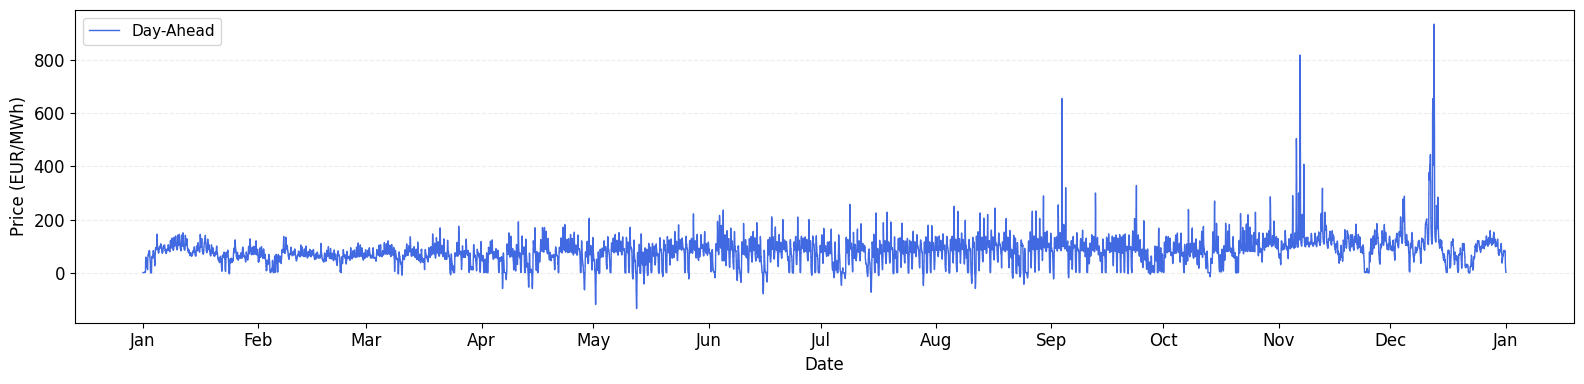

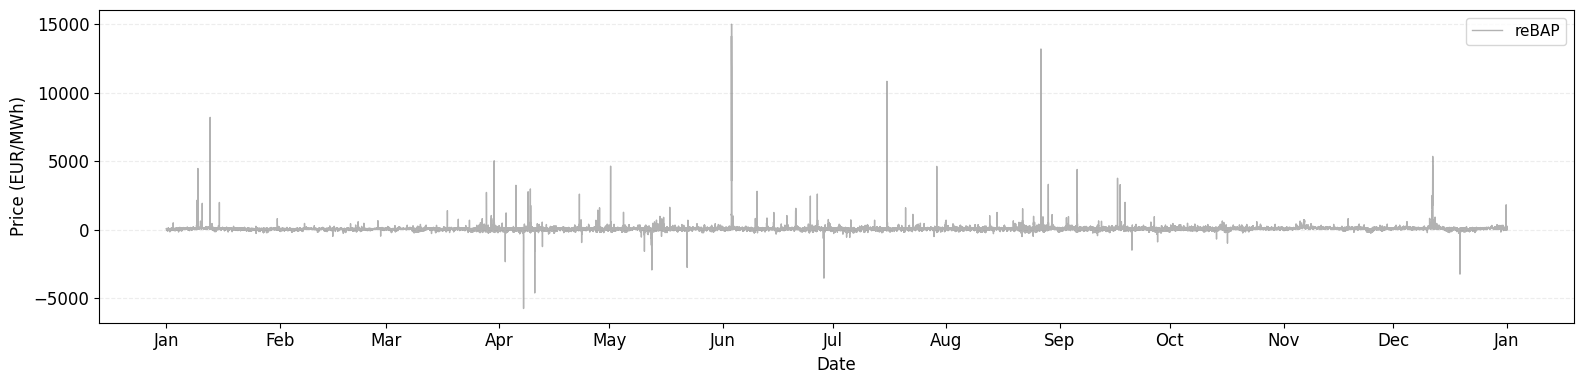

In [101]:
plt.figure(figsize=(16, 4))
plt.plot(market_prices['timestamp_local'], market_prices['day_ahead_price_eur_mwh'], color='royalblue', linewidth=1, label='Day-Ahead')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(tz='Europe/Berlin'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b', tz='Europe/Berlin'))
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 4 Day-Ahead Prices.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 4 Day-Ahead Prices.png', dpi=300, transparent=True)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(market_prices['timestamp_local'], market_prices['imbalance_price_eur_mwh'], color='gray', linewidth=1, alpha=0.6, label='reBAP')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(tz='Europe/Berlin'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b', tz='Europe/Berlin'))
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'Exhibit 4 reBAP Prices.pdf', transparent=True)
plt.savefig(figures_dir / 'Exhibit 4 reBAP Prices.png', dpi=300, transparent=True)
plt.show()

In [102]:
quantiles = [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]
price_distribution = pd.DataFrame({'Day-Ahead EUR/MWh': day_ahead_hourly['day_ahead_price_eur_mwh'].quantile(quantiles), 'reBAP EUR/MWh': market_prices['imbalance_price_eur_mwh'].quantile(quantiles)})
price_distribution.index = ['Minimum', '1%', '5%', '25%', 'Median', '75%', '95%', '99%', 'Maximum']
price_summary = pd.DataFrame({
    'Market': ['Day-Ahead', 'reBAP'], 'Observations': [len(day_ahead_hourly), len(market_prices)],
    'Mean EUR/MWh': [day_ahead_hourly['day_ahead_price_eur_mwh'].mean(), market_prices['imbalance_price_eur_mwh'].mean()],
    'Std EUR/MWh': [day_ahead_hourly['day_ahead_price_eur_mwh'].std(), market_prices['imbalance_price_eur_mwh'].std()],
    'Minimum EUR/MWh': [day_ahead_hourly['day_ahead_price_eur_mwh'].min(), market_prices['imbalance_price_eur_mwh'].min()],
    'Maximum EUR/MWh': [day_ahead_hourly['day_ahead_price_eur_mwh'].max(), market_prices['imbalance_price_eur_mwh'].max()]
})
daily_volatility = market_prices.groupby('local_date')[['day_ahead_price_eur_mwh', 'imbalance_price_eur_mwh']].std()
high_price_event_date = market_prices.groupby('local_date')['day_ahead_price_eur_mwh'].max().idxmax()

day_ahead_extremes = pd.concat([day_ahead_hourly.nlargest(5, 'day_ahead_price_eur_mwh').assign(Market='Day-Ahead', Direction='Highest'), day_ahead_hourly.nsmallest(5, 'day_ahead_price_eur_mwh').assign(Market='Day-Ahead', Direction='Lowest')])
rebap_extremes = pd.concat([market_prices.nlargest(5, 'imbalance_price_eur_mwh').assign(Market='reBAP', Direction='Highest'), market_prices.nsmallest(5, 'imbalance_price_eur_mwh').assign(Market='reBAP', Direction='Lowest')])
day_ahead_extremes['Price EUR/MWh'] = day_ahead_extremes['day_ahead_price_eur_mwh']
rebap_extremes['Price EUR/MWh'] = rebap_extremes['imbalance_price_eur_mwh']
price_extremes = pd.concat([day_ahead_extremes, rebap_extremes], ignore_index=True)[['Market', 'Direction', 'timestamp_local', 'Price EUR/MWh']]

print(price_summary.round(2).to_string(index=False))
print('\n' + price_distribution.round(2).to_string())
print('\nHighest and Lowest Prices\n' + price_extremes.round({'Price EUR/MWh': 2}).to_string(index=False))
print('\nHighest Day-Ahead Volatility Days\n' + daily_volatility['day_ahead_price_eur_mwh'].nlargest(5).round(2).to_string())
print('\nHighest reBAP Volatility Days\n' + daily_volatility['imbalance_price_eur_mwh'].nlargest(5).round(2).to_string())

   Market  Observations  Mean EUR/MWh  Std EUR/MWh  Minimum EUR/MWh  Maximum EUR/MWh
Day-Ahead          8784         78.51        52.73          -135.45           936.28
    reBAP         35136         85.77       282.66         -5734.46         14999.99

         Day-Ahead EUR/MWh  reBAP EUR/MWh
Minimum            -135.45       -5734.46
1%                  -19.95        -175.64
5%                   -0.01         -96.71
25%                  55.56          17.16
Median               79.59          89.96
75%                 101.34         135.62
95%                 143.25         220.53
99%                 224.86         447.85
Maximum             936.28       14999.99

Highest and Lowest Prices
   Market Direction           timestamp_local  Price EUR/MWh
Day-Ahead   Highest 2024-12-12 17:00:00+01:00         936.28
Day-Ahead   Highest 2024-11-06 17:00:00+01:00         820.11
Day-Ahead   Highest 2024-12-12 16:00:00+01:00         818.98
Day-Ahead   Highest 2024-11-06 18:00:00+01:00        

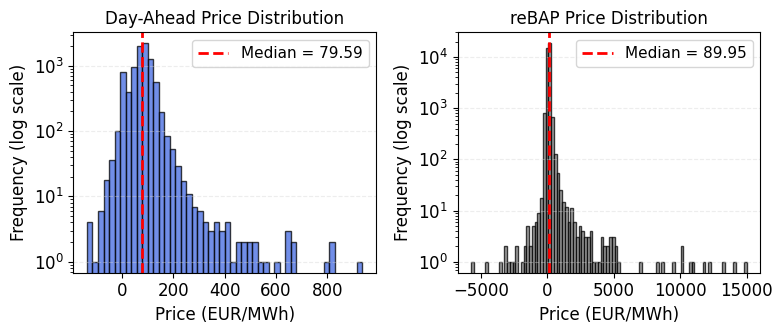

In [103]:
day_ahead_histogram = day_ahead_hourly['day_ahead_price_eur_mwh']
rebap_histogram = market_prices['imbalance_price_eur_mwh']
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for axis, data, title, color, bins in zip(axes, [day_ahead_histogram, rebap_histogram], ['Day-Ahead', 'reBAP'], ['royalblue', 'gray'], [50, 100]):
    axis.hist(data, bins=bins, color=color, edgecolor='black', alpha=0.75)
    axis.axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Median = {data.median():.2f}')
    axis.set_xlabel('Price (EUR/MWh)')
    axis.set_ylabel('Frequency (log scale)')
    axis.set_title(f'{title} Price Distribution')
    axis.set_yscale('log')
    axis.grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
    axis.legend()

fig.tight_layout()
fig.savefig(figures_dir / 'Exhibit 4 Price Distributions.pdf', transparent=True)
fig.savefig(figures_dir / 'Exhibit 4 Price Distributions.png', dpi=300, transparent=True)
plt.show()

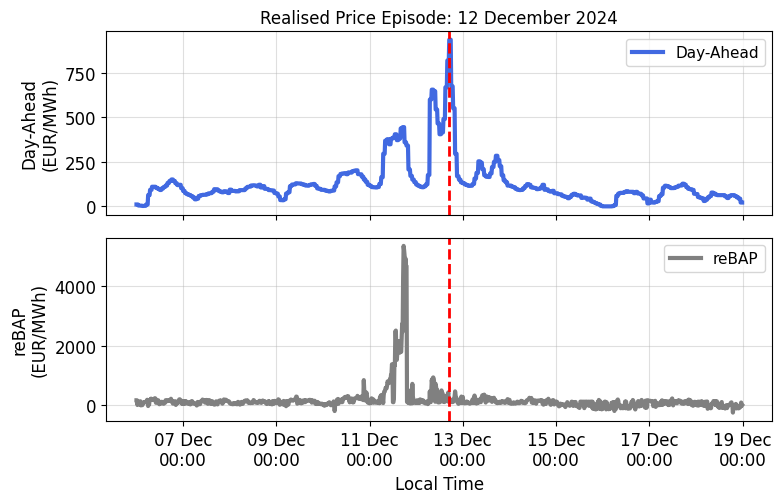

In [104]:
episode_center = pd.Timestamp(high_price_event_date, tz='Europe/Berlin')
episode_start = episode_center - pd.Timedelta(days=6)
episode_end = episode_center + pd.Timedelta(days=7)
december_episode = market_prices.loc[market_prices['timestamp_local'].ge(episode_start) & market_prices['timestamp_local'].lt(episode_end)].copy()
maximum_day_ahead_row = december_episode.loc[december_episode['day_ahead_price_eur_mwh'].idxmax()]

fig, axes = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
axes[0].plot(december_episode['timestamp_local'], december_episode['day_ahead_price_eur_mwh'], color='royalblue', linewidth=3, label='Day-Ahead')
axes[0].axvline(maximum_day_ahead_row['timestamp_local'], color='red', linestyle='--', linewidth=2)
axes[0].set_ylabel('Day-Ahead\n(EUR/MWh)')
axes[0].set_title(f'Realised Price Episode: {episode_center:%d %B %Y}')
axes[0].grid(True, alpha=0.4)
axes[0].legend()
axes[1].plot(december_episode['timestamp_local'], december_episode['imbalance_price_eur_mwh'], color='gray', linewidth=3, label='reBAP')
axes[1].axvline(maximum_day_ahead_row['timestamp_local'], color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Local Time')
axes[1].set_ylabel('reBAP\n(EUR/MWh)')
axes[1].grid(True, alpha=0.4)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M', tz='Europe/Berlin'))
fig.tight_layout()
fig.savefig(figures_dir / 'Exhibit 4 December Episode.pdf', transparent=True)
fig.savefig(figures_dir / 'Exhibit 4 December Episode.png', dpi=300, transparent=True)
plt.show()

In [105]:
rebap_maximum_row = market_prices.loc[market_prices['imbalance_price_eur_mwh'].idxmax()]
rebap_minimum_row = market_prices.loc[market_prices['imbalance_price_eur_mwh'].idxmin()]
december_day = market_prices.loc[market_prices['local_date'].eq(high_price_event_date)]
volatility_ratio = market_prices['imbalance_price_eur_mwh'].std() / day_ahead_hourly['day_ahead_price_eur_mwh'].std()
day_ahead_negative_count = day_ahead_hourly['day_ahead_price_eur_mwh'].lt(0).sum()
rebap_negative_count = market_prices['imbalance_price_eur_mwh'].lt(0).sum()
rebap_volatility_date = daily_volatility['imbalance_price_eur_mwh'].idxmax()

display(Markdown(f"""
### Interpretation

- **Distribution:** Average prices are of a similar order, but reBAP standard deviation is **{market_prices['imbalance_price_eur_mwh'].std():,.2f} EUR/MWh**, versus **{day_ahead_hourly['day_ahead_price_eur_mwh'].std():,.2f} EUR/MWh** for Day-Ahead - a **{volatility_ratio:.1f}x** ratio. The quantiles and histograms show much heavier reBAP tails.
- **Extremes:** Day-Ahead ranges from **{day_ahead_hourly['day_ahead_price_eur_mwh'].min():,.2f}** to **{day_ahead_hourly['day_ahead_price_eur_mwh'].max():,.2f} EUR/MWh**, with **{day_ahead_negative_count:,} of {len(day_ahead_hourly):,} ({day_ahead_negative_count / len(day_ahead_hourly):.3%})** hourly observations below zero. reBAP ranges from **{market_prices['imbalance_price_eur_mwh'].min():,.2f}** at **{rebap_minimum_row['timestamp_local']:%Y-%m-%d %H:%M %Z}** to **{market_prices['imbalance_price_eur_mwh'].max():,.2f} EUR/MWh** at **{rebap_maximum_row['timestamp_local']:%Y-%m-%d %H:%M %Z}**, with **{rebap_negative_count:,} of {len(market_prices):,} ({rebap_negative_count / len(market_prices):.3%})** observations below zero.
- **Other stress evidence:** The maximum reBAP occurred on **{rebap_maximum_row['timestamp_local']:%Y-%m-%d}**, which is also the highest reBAP daily-volatility date (**{rebap_volatility_date}**), while the simultaneous Day-Ahead price was **{rebap_maximum_row['day_ahead_price_eur_mwh']:,.2f} EUR/MWh**. This shows that imbalance stress can occur without a comparable wholesale-price spike; the price alone does not quantify portfolio cost without the associated imbalance volume.
- **Selected December episode:** **{high_price_event_date}** contains the annual Day-Ahead maximum of **{maximum_day_ahead_row['day_ahead_price_eur_mwh']:,.2f} EUR/MWh** at **{maximum_day_ahead_row['timestamp_local']:%H:%M %Z}** and the highest daily Day-Ahead volatility. That day's reBAP range is **{december_day['imbalance_price_eur_mwh'].min():,.2f}** to **{december_day['imbalance_price_eur_mwh'].max():,.2f} EUR/MWh**.
- **Information timing:** Day-Ahead and reBAP are realised 2024 prices. They describe the ex-post market environment and were not available when the 29 September 2023 futures snapshot was observed.
"""))


### Interpretation

- **Distribution:** Average prices are of a similar order, but reBAP standard deviation is **282.66 EUR/MWh**, versus **52.73 EUR/MWh** for Day-Ahead - a **5.4x** ratio. The quantiles and histograms show much heavier reBAP tails.
- **Extremes:** Day-Ahead ranges from **-135.45** to **936.28 EUR/MWh**, with **457 of 8,784 (5.203%)** hourly observations below zero. reBAP ranges from **-5,734.46** at **2024-04-07 14:15 CEST** to **14,999.99 EUR/MWh** at **2024-06-03 09:00 CEST**, with **6,962 of 35,136 (19.814%)** observations below zero.
- **Other stress evidence:** The maximum reBAP occurred on **2024-06-03**, which is also the highest reBAP daily-volatility date (**2024-06-03**), while the simultaneous Day-Ahead price was **128.08 EUR/MWh**. This shows that imbalance stress can occur without a comparable wholesale-price spike; the price alone does not quantify portfolio cost without the associated imbalance volume.
- **Selected December episode:** **2024-12-12** contains the annual Day-Ahead maximum of **936.28 EUR/MWh** at **17:00 CET** and the highest daily Day-Ahead volatility. That day's reBAP range is **33.50** to **931.41 EUR/MWh**.
- **Information timing:** Day-Ahead and reBAP are realised 2024 prices. They describe the ex-post market environment and were not available when the 29 September 2023 futures snapshot was observed.


## Close the briefing


In [106]:
analytical_files = {'SLP': slp, 'Shape Factors': shape_factors, 'Day-Ahead': day_ahead, 'Actual Load': actual_load, 'reBAP': imbalance}
analytical_keys = {name: pd.to_datetime(data['timestamp_utc'], utc=True) for name, data in analytical_files.items()}
reference_key = analytical_keys['SLP']
day_ahead_hour_counts = market_prices.groupby('utc_hour')['day_ahead_price_eur_mwh'].agg(['size', 'nunique'])
local_day_counts = customer_profile.groupby(customer_profile['timestamp_local'].dt.date).size()
actual_component_check = np.allclose(actual_load[['hb_actual_mwh', 'gb_actual_mwh', 'lb_actual_mwh']].sum(axis=1), actual_load['total_actual_mwh'], atol=1e-6)

coverage_checks = {}
for coverage_name, periods in coverage_sets.items():
    coverage_rows = futures_data.loc[futures_data['load_type'].eq('BASE') & futures_data['delivery_period'].isin(periods)].sort_values('delivery_start')
    coverage_checks[coverage_name] = coverage_rows['delivery_start'].iloc[0] == pd.Timestamp('2024-01-01') and coverage_rows['delivery_end_exclusive'].iloc[-1] == pd.Timestamp('2025-01-01') and coverage_rows['delivery_start'].iloc[1:].reset_index(drop=True).equals(coverage_rows['delivery_end_exclusive'].iloc[:-1].reset_index(drop=True))

expected_result_files = [
    'Exhibit 1 Annual Energy Pie Chart.png',
    'Exhibit 1 Average Daily Profiles.png',
    'Exhibit 1 Weekday vs Weekend.png',
    'Exhibit 2 Market Activity.png',
    'Exhibit 2 Futures Prices.png',
    'Exhibit 3 Historical Price Shape.png',
    'Exhibit 4 Day-Ahead Prices.png',
    'Exhibit 4 reBAP Prices.png',
    'Exhibit 4 Price Distributions.png',
    'Exhibit 4 December Episode.png'
]

expected_result_files = [str(Path(filename).with_suffix(extension)) for filename in expected_result_files for extension in ['.pdf', '.png']]
saved_result_files = [filename for filename in expected_result_files if (figures_dir / filename).exists() and (figures_dir / filename).stat().st_size > 0]
result_files_saved = len(saved_result_files) == len(expected_result_files)

final_checks = pd.DataFrame([
    {'Dataset': 'All time series', 'Check': '35,136 rows and unique UTC keys', 'Observed': ', '.join(f'{name}: {len(data):,}/{analytical_keys[name].nunique():,}' for name, data in analytical_files.items()), 'Expected': '35,136/35,136 each', 'Passed': all(len(data) == 35136 and analytical_keys[name].nunique() == 35136 for name, data in analytical_files.items())},
    {'Dataset': 'All time series', 'Check': 'UTC keys align', 'Observed': str(all(reference_key.equals(key) for key in analytical_keys.values())), 'Expected': 'True', 'Passed': all(reference_key.equals(key) for key in analytical_keys.values())},
    {'Dataset': 'SLP', 'Check': 'No missing, duplicate, or negative profile values', 'Observed': f"{slp[profile_columns].isna().sum().sum()}/{slp['timestamp_utc'].duplicated().sum()}/{slp[profile_columns].lt(0).sum().sum()}", 'Expected': '0/0/0', 'Passed': slp[profile_columns].isna().sum().sum() == 0 and slp['timestamp_utc'].duplicated().sum() == 0 and slp[profile_columns].lt(0).sum().sum() == 0},
    {'Dataset': 'SLP', 'Check': 'Normalized annual profile totals', 'Observed': ', '.join(f'{value:,.3f}' for value in annual_slp_mwh), 'Expected': '1,000 MWh each', 'Passed': np.allclose(annual_slp_mwh, 1000)},
    {'Dataset': 'Portfolio', 'Check': 'Group and total annual energy reconcile', 'Observed': ', '.join(f'{value:,.0f}' for value in energy_reconciliation['Calculated MWh']), 'Expected': '35,000 / 6,000 / 2,000 / 43,000', 'Passed': energy_reconciliation['Reconciled'].all()},
    {'Dataset': 'Portfolio', 'Check': 'Quarter-hour MWh to MW identity', 'Observed': f"max diff {np.abs(customer_profile['total_mw'] * 0.25 - customer_profile['total_mwh']).max():.3e}", 'Expected': '0', 'Passed': np.allclose(customer_profile['total_mw'] * 0.25, customer_profile['total_mwh'])},
    {'Dataset': 'Futures', 'Check': 'Unique Base/Peak pair for every period', 'Observed': f"keys={futures_data[['delivery_period', 'load_type']].drop_duplicates().shape[0]}, periods={futures_data['delivery_period'].nunique()}", 'Expected': '34 keys / 17 periods', 'Passed': futures_data.duplicated(['delivery_period', 'load_type']).sum() == 0 and futures_data.groupby('delivery_period')['load_type'].nunique().eq(2).all()},
    {'Dataset': 'Futures', 'Check': 'Prices/activity valid and coverages non-overlapping', 'Observed': f"missing={futures_data[['price_eur_mwh', 'market_activity']].isna().sum().sum()}, negative activity={futures_data['market_activity'].lt(0).sum()}, coverage={coverage_checks}", 'Expected': '0 / 0 / all True', 'Passed': futures_data[['price_eur_mwh', 'market_activity']].isna().sum().sum() == 0 and futures_data['market_activity'].ge(0).all() and all(coverage_checks.values())},
    {'Dataset': 'Shape Factors', 'Check': 'Positive values, mean one, valid codes', 'Observed': f"min={shape_data['historical_shape_factor'].min():.3f}, mean={shape_data['historical_shape_factor'].mean():.6f}, weekday={sorted(shape_data['weekday'].unique())}, peak={sorted(shape_data['is_peak'].unique())}", 'Expected': 'min>0 / mean=1 / 0-6 / 0-1', 'Passed': shape_data['historical_shape_factor'].gt(0).all() and np.isclose(shape_data['historical_shape_factor'].mean(), 1) and set(shape_data['weekday'].unique()) == set(range(7)) and set(shape_data['is_peak'].unique()) == {0, 1}},
    {'Dataset': 'Shape Factors', 'Check': 'Peak matches Berlin weekday 08:00-20:00', 'Observed': f"mismatches={shape_data['is_peak'].ne(shape_data['local_peak_check'].astype(int)).sum()}", 'Expected': '0', 'Passed': shape_data['is_peak'].eq(shape_data['local_peak_check'].astype(int)).all()},
    {'Dataset': 'Day-Ahead', 'Check': 'One hourly value repeated four quarter-hours', 'Observed': f"hours={len(day_ahead_hour_counts)}, invalid={((day_ahead_hour_counts['size'] != 4) | (day_ahead_hour_counts['nunique'] != 1)).sum()}", 'Expected': '8,784 / 0', 'Passed': len(day_ahead_hour_counts) == 8784 and day_ahead_hour_counts['size'].eq(4).all() and day_ahead_hour_counts['nunique'].eq(1).all()},
    {'Dataset': 'Realised Prices', 'Check': 'Positive and negative observations retained', 'Observed': f"DA {day_ahead_hourly['day_ahead_price_eur_mwh'].min():.2f}/{day_ahead_hourly['day_ahead_price_eur_mwh'].max():.2f}; reBAP {market_prices['imbalance_price_eur_mwh'].min():.2f}/{market_prices['imbalance_price_eur_mwh'].max():.2f}", 'Expected': 'min<0 and max>0', 'Passed': day_ahead_hourly['day_ahead_price_eur_mwh'].min() < 0 < day_ahead_hourly['day_ahead_price_eur_mwh'].max() and market_prices['imbalance_price_eur_mwh'].min() < 0 < market_prices['imbalance_price_eur_mwh'].max()},
    {'Dataset': 'Actual Load', 'Check': 'Customer components reconcile to total', 'Observed': str(actual_component_check), 'Expected': 'True', 'Passed': actual_component_check},
    {'Dataset': 'Calendar', 'Check': 'Berlin DST days and December event', 'Observed': f"intervals={sorted(local_day_counts.unique())}, event={high_price_event_date}", 'Expected': '92/96/100 and December', 'Passed': set(local_day_counts.unique()) == {92, 96, 100} and high_price_event_date.month == 12 and not december_episode.empty},
    {'Dataset': 'Results', 'Check': 'All expected figures saved and non-empty', 'Observed': f'{len(saved_result_files)}/{len(expected_result_files)} files', 'Expected': f'{len(expected_result_files)}/{len(expected_result_files)} files', 'Passed': result_files_saved}
])

print(final_checks[['Dataset', 'Check', 'Passed']].to_string(index=False))
assert final_checks['Passed'].all(), final_checks.loc[~final_checks['Passed']].to_dict('records')

display(Markdown(f"""
### Closing
            

1. **Information timing:** The customer assumptions, standardized profiles, historical 2019-2022 shape factors, and the futures snapshot dated 29 September 2023 were available ex ante. Actual 2024 load, Day-Ahead prices, and reBAP were revealed only during delivery.
2. **Data checks:** **{final_checks['Passed'].sum()} of {len(final_checks)} checks passed.** The checks cover structure, missingness, duplicate UTC keys, negative values where inappropriate, expected annual sums and means, portfolio reconciliation, Base/Peak completeness, non-overlapping coverage, Peak coding, hourly Day-Ahead repetition, DST-aware local days, realised-price ranges, and saved figure files.
3. **Missing information and market features:**
   - **Demand:** Customers are treated as homogeneous within HB, GB, and LB, and demand is built from standardized profiles plus fixed annual consumption. Weather, holidays, behavioural or structural change, customer churn, and forecast uncertainty could systematically over- or under-size the forecast portfolio.
   - **Market:** Futures are represented by one price snapshot and a simplified activity indicator. Bid-ask spreads, order-book depth, transaction costs, collateral or margin requirements, changing liquidity, and changing prices could make apparently usable contracts more costly or difficult to execute.
   - **Instrument set:** Standard Base and Peak products cannot reproduce the portfolio's full quarter-hourly shape. Dynamic rebalancing, OTC or structured products, and shorter-dated instruments could reduce residual volume and shape risk but are outside this data briefing.
"""))

for filename, table in {'00_data_summary': data_summary, '00_portfolio_summary': profile_summary, '00_energy_reconciliation': energy_reconciliation, '00_futures_market': futures_market_table, '00_price_summary': price_summary, '00_price_extremes': price_extremes, '00_data_checks': final_checks}.items():
    table.to_csv(table_dir / f'{filename}.csv', index=False)
price_distribution.to_csv(table_dir / '00_price_distribution.csv', index_label='Quantile')

        Dataset                                               Check  Passed
All time series                     35,136 rows and unique UTC keys    True
All time series                                      UTC keys align    True
            SLP   No missing, duplicate, or negative profile values    True
            SLP                    Normalized annual profile totals    True
      Portfolio             Group and total annual energy reconcile    True
      Portfolio                     Quarter-hour MWh to MW identity    True
        Futures              Unique Base/Peak pair for every period    True
        Futures Prices/activity valid and coverages non-overlapping    True
  Shape Factors              Positive values, mean one, valid codes    True
  Shape Factors             Peak matches Berlin weekday 08:00-20:00    True
      Day-Ahead        One hourly value repeated four quarter-hours    True
Realised Prices         Positive and negative observations retained    True
    Actual L


### Closing
            

1. **Information timing:** The customer assumptions, standardized profiles, historical 2019-2022 shape factors, and the futures snapshot dated 29 September 2023 were available ex ante. Actual 2024 load, Day-Ahead prices, and reBAP were revealed only during delivery.
2. **Data checks:** **15 of 15 checks passed.** The checks cover structure, missingness, duplicate UTC keys, negative values where inappropriate, expected annual sums and means, portfolio reconciliation, Base/Peak completeness, non-overlapping coverage, Peak coding, hourly Day-Ahead repetition, DST-aware local days, realised-price ranges, and saved figure files.
3. **Missing information and market features:**
   - **Demand:** Customers are treated as homogeneous within HB, GB, and LB, and demand is built from standardized profiles plus fixed annual consumption. Weather, holidays, behavioural or structural change, customer churn, and forecast uncertainty could systematically over- or under-size the forecast portfolio.
   - **Market:** Futures are represented by one price snapshot and a simplified activity indicator. Bid-ask spreads, order-book depth, transaction costs, collateral or margin requirements, changing liquidity, and changing prices could make apparently usable contracts more costly or difficult to execute.
   - **Instrument set:** Standard Base and Peak products cannot reproduce the portfolio's full quarter-hourly shape. Dynamic rebalancing, OTC or structured products, and shorter-dated instruments could reduce residual volume and shape risk but are outside this data briefing.
